In [1]:
conda activate xregrid_env

usage: conda [-h] [-v] [--no-plugins] [-V] COMMAND ...
conda: error: argument COMMAND: invalid choice: 'activate' (choose from 'clean', 'compare', 'config', 'create', 'info', 'init', 'install', 'list', 'notices', 'package', 'remove', 'uninstall', 'rename', 'run', 'search', 'update', 'upgrade', 'doctor', 'repoquery', 'env')

Note: you may need to restart the kernel to use updated packages.


In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import xarray as xr
from matplotlib.colors import Normalize
from xregrid import Regridder

In [3]:
file = "/glade/campaign/acom/acom-weather/emmons/ASIAAQ_sims/f.e3b06m.FCnudged.t6s.GEMSne30x8.01/atm/hist/f.e3b06m.FCnudged.t6s.GEMSne30x8.01.cam.h1a.2024-03-14-00000.nc"
scrip_file = "/glade/work/emmons/VRM_Files/ne0np4.GEMS01.ne30x8/grids/GEMS01_ne30x8_np4_SCRIP.nc"
mesh_file = "/glade/work/emmons/VRM_Files/ne0np4.GEMS01.ne30x8/grids/GEMS01_ne30x8_np4_MESH.nc"
ds = xr.open_dataset(file)
scrip_ds = xr.open_dataset(scrip_file)
mesh_ds = xr.open_dataset(mesh_file)


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection

# 读取 scrip 数据
lon_b = scrip_ds['grid_corner_lon'].values  # (grid_size, nvertex)
lat_b = scrip_ds['grid_corner_lat'].values

lon_b = np.where(lon_b > 180, 
                 lon_b - 360,
                 lon_b)

def unwrap_cell(lon):
    lon = lon.copy()
    ref = lon[0]

    for i in range(1, len(lon)):
        diff = lon[i] - ref

        if diff > 180:
            lon[i] -= 360
        elif diff < -180:
            lon[i] += 360

    return lon

data = (ds['NO2']
        .isel(time=0, lev=-1)
        .values
        .astype(float)
        * 1e9)

# 构造 polygon 顶点
polygons = []

for i in range(len(lon_b)):
    lon = unwrap_cell(lon_b[i])
    lat = lat_b[i]

    polygons.append(np.column_stack([lon, lat]))

import cartopy.crs as ccrs

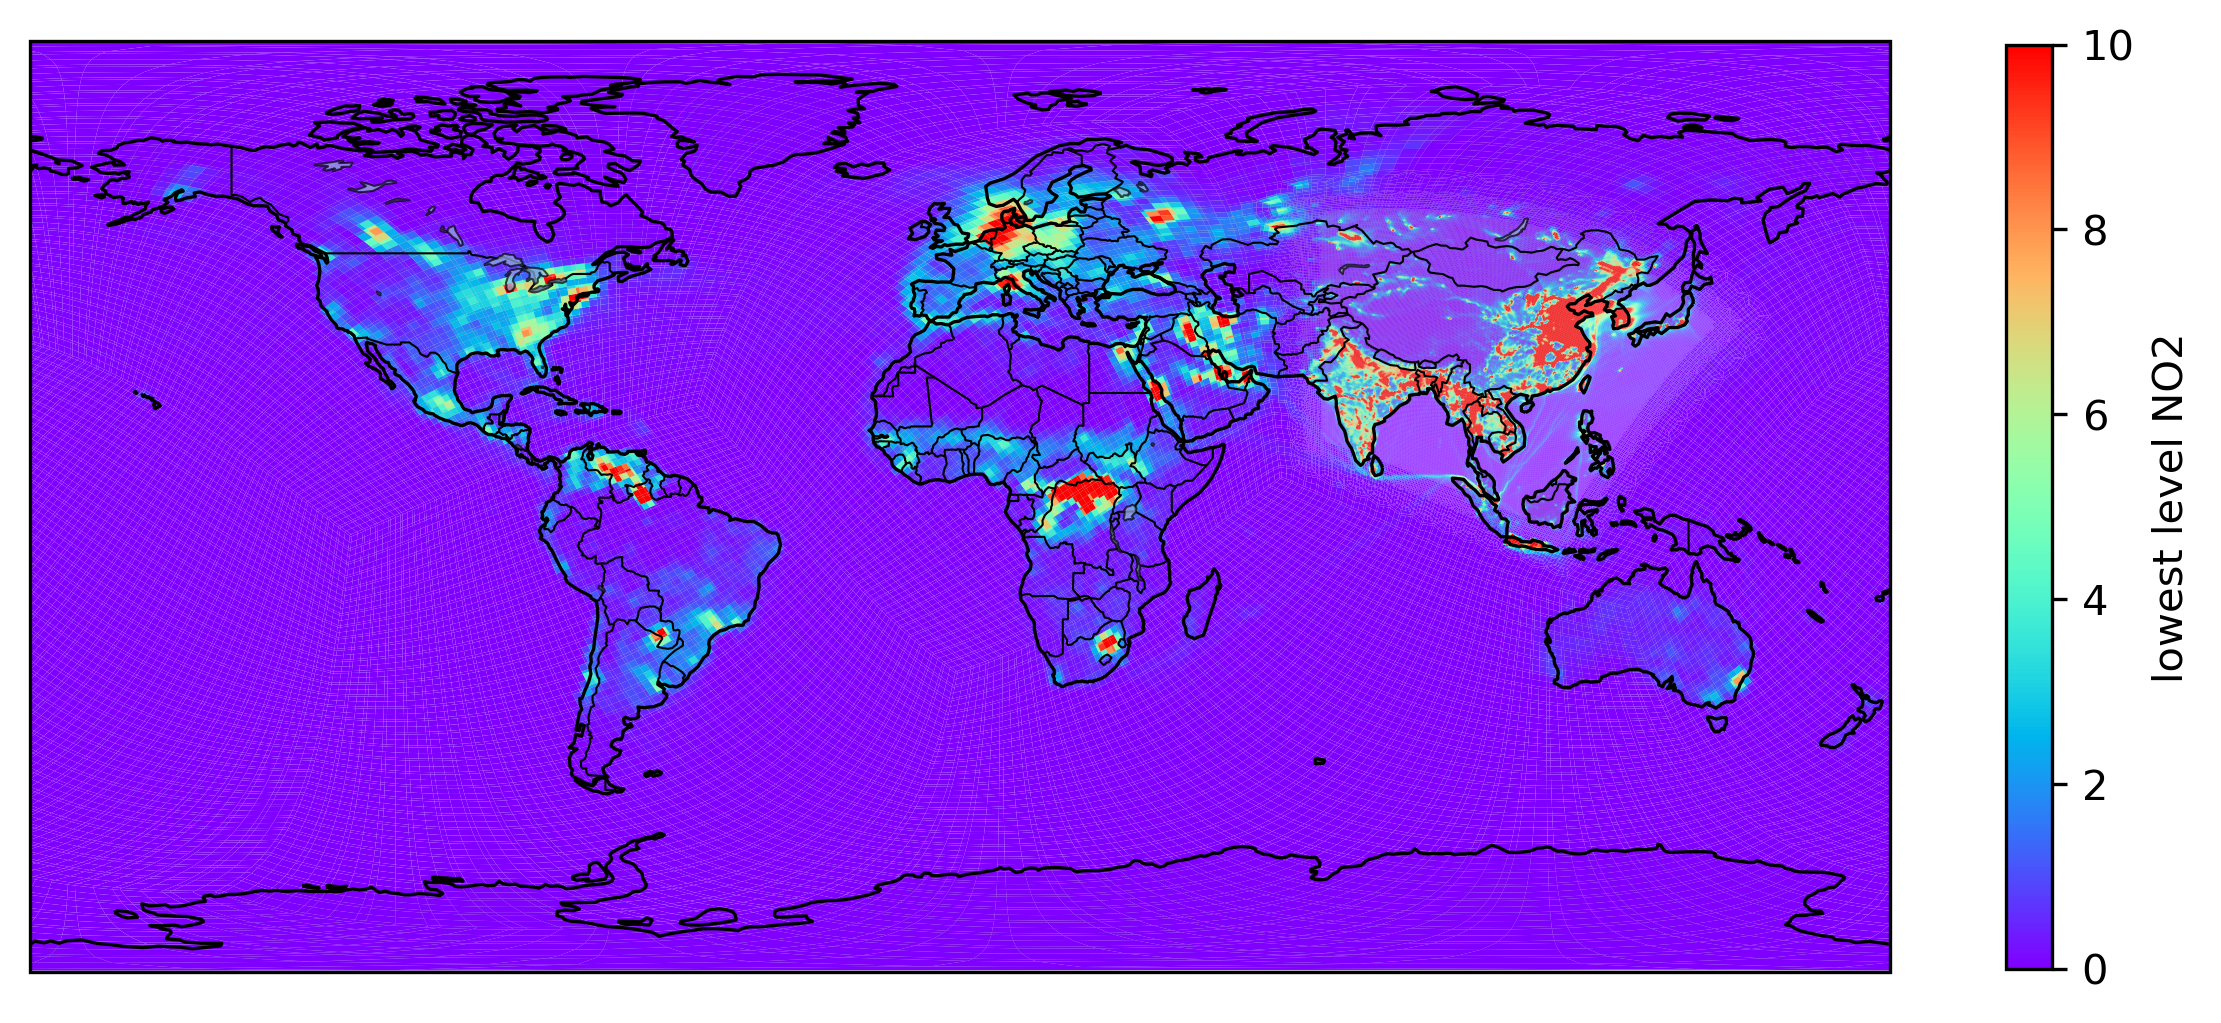

In [5]:
fig = plt.figure(figsize=(10,8),dpi=300)
ax = plt.axes(projection=ccrs.PlateCarree())
# 添加背景
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='white')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAKES, linewidth=0.5, alpha=0.7, edgecolor='black')


# 设置颜色归一化
norm = Normalize(vmin=0, vmax=10)

# PolyCollection 绘制
collection = PolyCollection(
    polygons,
    array=data,
    cmap='rainbow',
    edgecolor='none',
    norm=norm,
    transform=ccrs.PlateCarree()
)
ax.add_collection(collection)
# 全局显示
ax.set_global()

# colorbar
plt.colorbar(collection, ax=ax, shrink = 0.5,label='lowest level NO2')

plt.show()

In [7]:
lon_b_wrap = np.zeros(scrip_ds['grid_corner_lon'].shape)
for i in range(len(polygons)):
    for j in range(len(polygons[i])):
        lon_b_wrap[i,j] = polygons[i][j][0].item()

In [8]:
lon_b_wrap

array([[ -3.00154847,  -2.94157268,  -2.68613214, ...,  -3.20501838,
         -3.20501838,  -3.20501838],
       [ -3.00154847,  -1.9741162 ,  -1.91993316, ...,  -2.94157268,
         -2.94157268,  -2.94157268],
       [ -1.9741162 ,  -0.93007133,  -0.88190646, ...,  -1.91993316,
         -1.91993316,  -1.91993316],
       ...,
       [145.09962698, 144.97269319, 145.10298823, ..., 145.24223394,
        145.24223394, 145.24223394],
       [145.38185758, 145.24223394, 145.38444908, ..., 145.53637917,
        145.53637917, 145.53637917],
       [145.24223394, 145.10298823, 145.23292742, ..., 145.38444908,
        145.38444908, 145.38444908]], shape=(248582, 12))

In [9]:
import numpy as np
import xarray as xr

# -----------------------------
# 1️⃣ SCRIP polygon 顶点
# lon_b, lat_b shape = (grid_size, nCorners)
lon_b = scrip_ds['grid_corner_lon'].values  # degrees
lat_b = scrip_ds['grid_corner_lat'].values

# 调整经度到 [-180,180]
#lon_b = np.where(lon_b > 180, lon_b - 360, lon_b)

# unwrap polygon
def unwrap_cell(lon):
    lon = lon.copy()
    ref = lon[0]

    for i in range(1, len(lon)):
        diff = lon[i] - ref

        if diff > 180:
            lon[i] -= 360
        elif diff < -180:
            lon[i] += 360

    return lon

#lon_b_unwrapped = np.array([unwrap_cell(lon_b[i]) for i in range(lon_b.shape[0])])
lon_b_unwrapped = lon_b

# -----------------------------
# 2️⃣ 构建唯一 vertex 并映射
# -----------------------------
grid_size, nCorners = lon_b.shape

# flatten 所有角点
all_vertices = np.column_stack([lat_b.flatten(), lon_b_unwrapped.flatten()])

# 找唯一顶点，并返回 inverse_idx
unique_vertices, inverse_idx = np.unique(all_vertices, axis=0, return_inverse=True)
latVertex = unique_vertices[:,0]
lonVertex = unique_vertices[:,1]
nVertices = len(latVertex)

# verticesOnCell: 重新映射
verticesOnCell = inverse_idx.reshape(grid_size, nCorners) + 1  # 1-based
# 去掉重复角点
nEdgesOnCell = np.array([len(np.unique(verticesOnCell[i])) for i in range(grid_size)])
maxNodes = nEdgesOnCell.max()

# 填充 verticesOnCell 到 maxNodes
verticesOnCell_padded = np.full((grid_size, maxNodes), -1, dtype=int)
for i in range(grid_size):
    unique_idx = np.unique(verticesOnCell[i])
    verticesOnCell_padded[i, :len(unique_idx)] = unique_idx

# -----------------------------
# 3️⃣ cell center
# -----------------------------
latCell = np.mean(lat_b, axis=1)
lonCell = np.mean(lon_b_unwrapped, axis=1)

# -----------------------------
# 4️⃣ 构建 ds_mpas_like
# -----------------------------
NO2_data = ds['NO2'].values  # shape = (time, lev, nCells)
# 如果 grid_size != nCells，需要先映射（此处假设一致）

ds_mpas_like = xr.Dataset(
    {
        "NO2": (["time","lev","nCells"], NO2_data)
    },
    coords = {
        "latCell": (["ncol"], np.deg2rad(latCell), {"units": "radians"}),
        "lonCell": (["ncol"], np.deg2rad(lonCell), {"units": "radians"}),
        "latVertex": (["nVertices"], np.deg2rad(latVertex), {"units": "radians"}),
        "lonVertex": (["nVertices"], np.deg2rad(lonVertex), {"units": "radians"}),
        "verticesOnCell": (["ncol", "maxNodes"], verticesOnCell_padded),
        "nEdgesOnCell": (["ncol"], nEdgesOnCell.astype(int)),
        "maxNodes": maxNodes,
    }
)

In [10]:
ds_mpas_like

<xarray.Dataset> Size: 68MB
Dimensions:         (time: 1, lev: 32, nCells: 248582, nVertices: 414300,
                     maxNodes: 12)
Coordinates:
  * time            (time) datetime64[ns] 8B 2024-03-13T12:00:00
  * lev             (lev) float64 256B 3.643 7.595 14.36 ... 957.5 976.3 992.6
    latCell         (nCells) float64 2MB -0.5288 -0.5376 -0.5517 ... 0.614 0.612
    lonCell         (nCells) float64 2MB 6.228 6.24 6.259 ... 2.532 2.538 2.535
    nEdgesOnCell    (nCells) int64 2MB 8 6 6 6 6 4 4 6 6 4 ... 4 4 4 6 6 4 4 4 4
    latVertex       (nVertices) float64 3MB -0.5354 -0.5314 ... 0.616 0.614
    lonVertex       (nVertices) float64 3MB 6.231 6.232 6.236 ... 2.532 2.535
    verticesOnCell  (nCells, maxNodes) float64 24MB 1.0 2.0 3.0 ... nan nan nan
Dimensions without coordinates: nCells, nVertices, maxNodes
Data variables:
    NO2             (time, lev, nCells) float32 32MB 1.231e-08 ... 1.796e-10

In [11]:
mesh_ds

<xarray.Dataset> Size: 38MB
Dimensions:         (nodeCount: 414300, coordDim: 2, elementCount: 248582,
                     maxNodePElement: 12)
Dimensions without coordinates: nodeCount, coordDim, elementCount,
                                maxNodePElement
Data variables:
    nodeCoords      (nodeCount, coordDim) float64 7MB ...
    elementConn     (elementCount, maxNodePElement) float64 24MB 1.0 2.0 ... nan
    numElementConn  (elementCount) int32 994kB 8 6 6 6 6 4 4 6 ... 4 6 6 4 4 4 4
    centerCoords    (elementCount, coordDim) float64 4MB ...
    elementArea     (elementCount) float64 2MB ...
    elementMask     (elementCount) int32 994kB ...
Attributes:
    gridType:       unstructured mesh
    version:        0.9
    inputFile:      /glade/work/emmons/VRM_Files//ne0np4.GEMS01.ne30x8/grids/...
    timeGenerated:  Tue Jul  2 17:21:12 2024

In [12]:
nEdgesOnCell = mesh_ds.numElementConn
verticesOnCell = mesh_ds.elementConn
latVertex = mesh_ds.nodeCoords[:,1]
lonVertex = mesh_ds.nodeCoords[:,0]
latCell = centerCoords[:,1]
lonCell = centerCoords[:,0]

NameError: name 'centerCoords' is not defined

In [ ]:
from xregrid import Regridder, create_global_grid

# 2. Define a rectilinear target grid (e.g., 5° global)
target_grid = create_global_grid(.5, .5)

# 3. Create the regridder using the 'conservative' method
# XRegrid will detect the MPAS connectivity and use ESMF Mesh
regridder = Regridder(ds_mpas_like, target_grid, method="conservative", periodic=True)

In [ ]:
# 4. Apply regridding
regridded = regridder(ds_mpas_like.NO2)
regridded

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import Normalize
import numpy as np

# -----------------------------
# 1️⃣ 提取最低层 NO2
# -----------------------------
data = regridded.isel(time=0, lev=-1).values * 1e9  # 转成 ppb
lat = regridded['lat'].values
lon = regridded['lon'].values

# -----------------------------
# 2️⃣ 绘图
# -----------------------------
fig, ax = plt.subplots(figsize=(12,8), dpi = 300, subplot_kw={'projection': ccrs.PlateCarree()})

# 背景
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='white')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAKES, linewidth=0.5, alpha=0.7, edgecolor='black')

# 设置颜色归一化
norm = Normalize(vmin=0, vmax=10)

# pcolormesh 绘制
# 注意 lat/lon 的 shape 要对应 data.shape
mesh = ax.pcolormesh(lon, lat, data, cmap='rainbow', norm=norm, shading='auto', transform=ccrs.PlateCarree())

# 全局显示
ax.set_global()
ax.set_title('MUSICA Lowest level NO2 (ppb) in 0.5 Grid')

# colorbar
plt.colorbar(mesh, ax=ax, shrink=0.6, label='NO2 (ppb)')

plt.show()